In [23]:
import numpy as np

def setup_tridiagonal_matrix(x, y):
    h = np.diff(x)
    A = []
    B = []
    C = []
    D = []
    
    for i in range(1, len(x)-1):
        leftSlope = (y[i] - y[i-1]) / h[i-1]
        rightSlope = (y[i+1] - y[i]) / h[i]
        A.append(h[i-1])
        B.append(2 * (h[i-1] + h[i]))
        C.append(h[i])
        D.append(6 * (rightSlope - leftSlope))
        
    return A, B, C, D

In [24]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [25]:
def evaluate_spline(x, y, m, xeval):
    lowerBound = 0
    upperBound = 1
    for i in range(len(x)-1):
        if (x[i] <= xeval <= x[i+1]):
            lowerBound = i
            upperBound = i+1
            break
    xL = x[lowerBound]
    xU = x[upperBound]
    yL = y[lowerBound]
    yU = y[upperBound]
    mL = m[lowerBound]
    mU = m[upperBound]
    h = xU - xL
    leftCurve = mL * (xU - xeval)**3 / (6*h)
    rightCurve = mU * (xeval - xL)**3 / (6*h)
    left = (yL - mL*h**2/6) * (xU - xeval) / h
    right = (yU - mU*h**2/6) * (xeval - xL) / h
    yValue = leftCurve + rightCurve + left + right
    return yValue

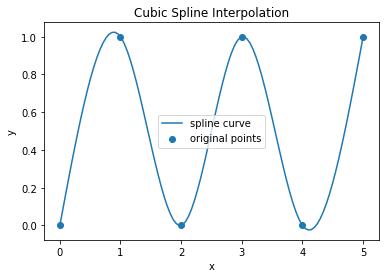

In [29]:
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
a, b, c, d = setup_tridiagonal_matrix(x, y)
mCalc = thomas_algorithm(a, b, c, d)
m = np.concatenate(([0], mCalc, [0]))
xnew = np.linspace(min(x), max(x),100)
ynew = []
for i in xnew:
    ynew.append(evaluate_spline(x, y, m, i))
plt.scatter(x, y, label="original points")
plt.plot(xnew, ynew, label = "spline curve")
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.show()